In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import yaml
import numpy as np

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

from irc.manager import IRCManager

# Train an agent

Agent (seed 0) was trained for 10 epochs, RL optimality 99.72%.


/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


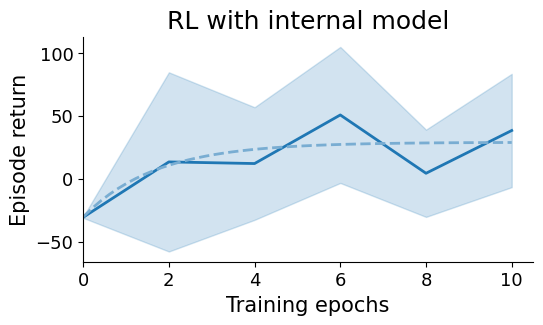

In [8]:
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)


env_param = [0, 1500, 0.087213, .25, -30, 0, 0]
num_epochs = 50
seed = 0
# agent = manager.train_agent(env_param, num_epochs=num_epochs, seed = seed)
agent, fig = manager.inspect_agent(env_param, figsize=(5, 2.5), seed = seed)

## Analysis within trial

### Visualize episode

[  0.          -0.31694253  -0.31694253  -0.31694253 -30.        ]


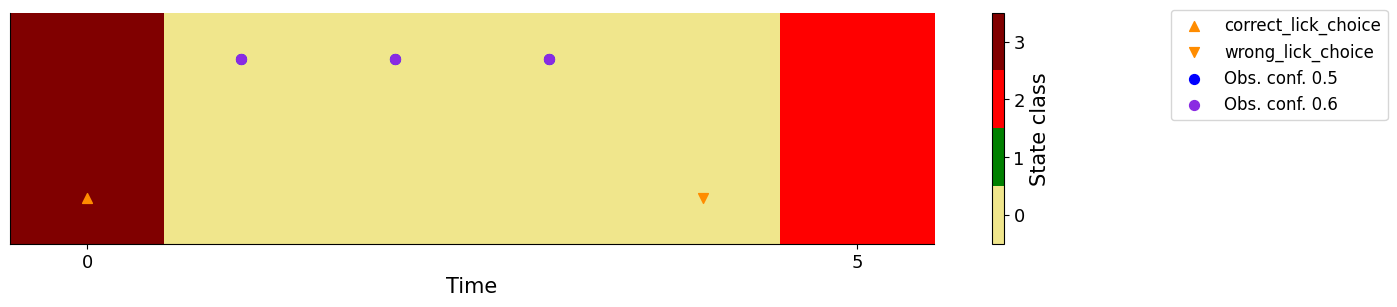

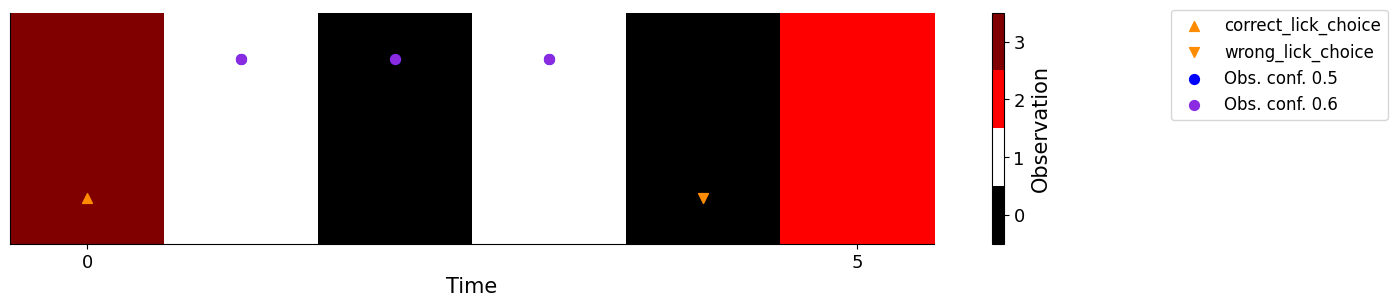

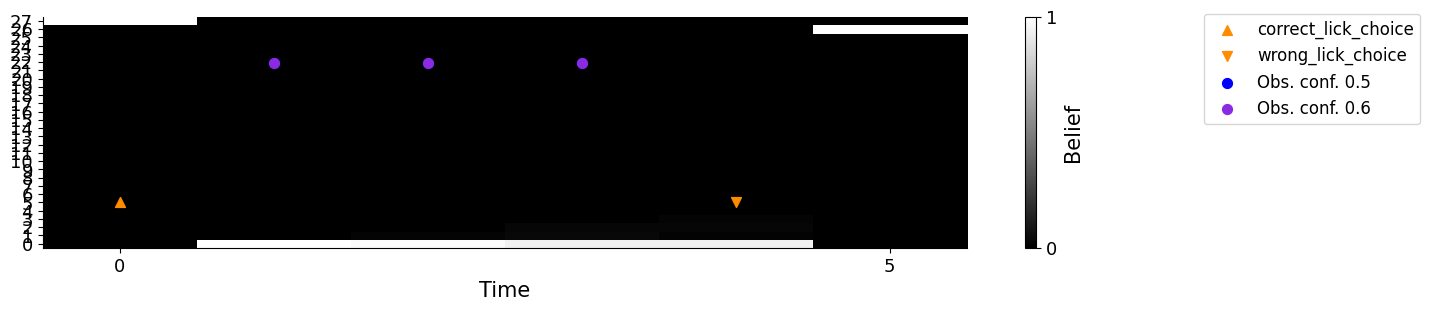

In [28]:
from auditoryforage.AF_env import AuditoryForaging
from auditoryforage.utils import plot_AF_episode
env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
fig = plot_AF_episode(episode, env, agent, nodes_from_zero = 40, time_steps_before_lick = 20)
print(episode['rewards'])

### Visualize action probabilities

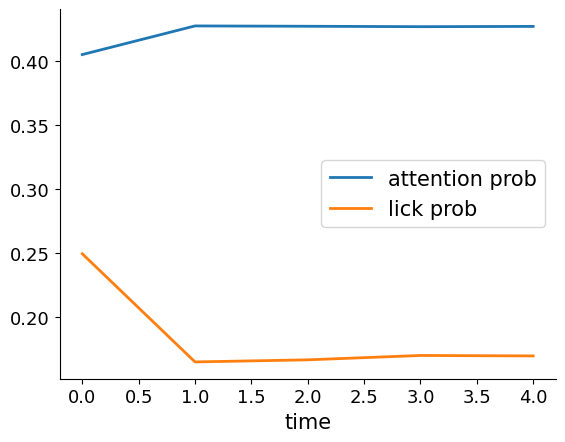

In [29]:
import torch
def find_activation(agent, belief):
    features = torch.tensor(belief, dtype=torch.float32)
    with torch.no_grad():
        policy_net_0_results = agent.algo.policy.mlp_extractor.policy_net[0](features)
        policy_net_1_results = agent.algo.policy.mlp_extractor.policy_net[1](policy_net_0_results)
        policy_net_2_results = agent.algo.policy.mlp_extractor.policy_net[2](policy_net_1_results)
        policy_net_3_results = agent.algo.policy.mlp_extractor.policy_net[3](policy_net_2_results)
        policy_net_4_results = agent.algo.policy.mlp_extractor.policy_net[4](policy_net_3_results)
    return policy_net_4_results

activations_list = []
for belief in episode['beliefs'][:-1]: #Last belief is not used for action
    activations_list.append(find_activation(agent, belief).numpy())


lick_feature = [activations_list[ind][0]  for ind in range(len(activations_list))]
attention_feature = [activations_list[ind][1] for ind in range(len(activations_list))]
plt.figure()
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in attention_feature], label = 'attention prob')
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in lick_feature], label = 'lick prob')
plt.xlabel('time')
plt.legend()
plt.show()

## Analysis over trials

### Time analysis - plots

Checkpoint (epoch 1) loaded.


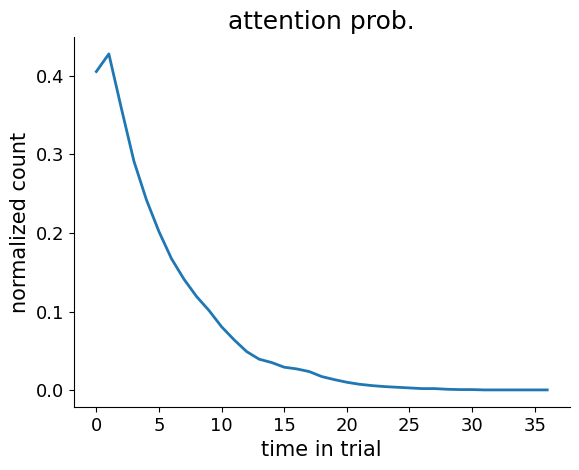

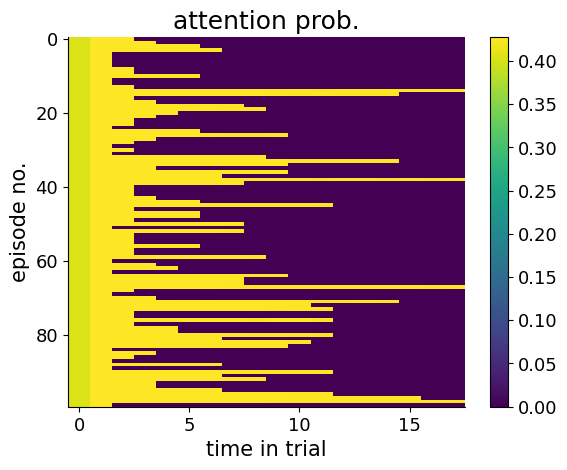

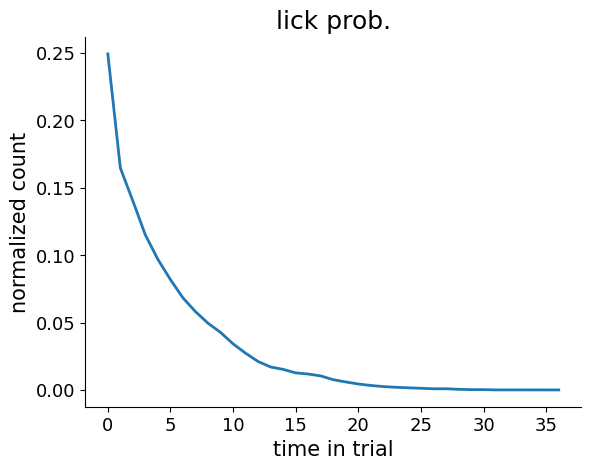

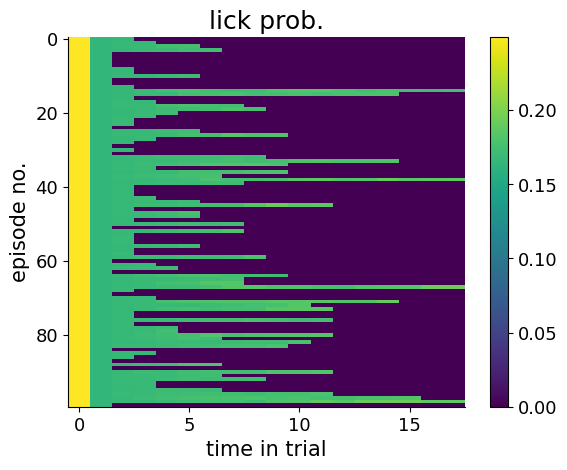

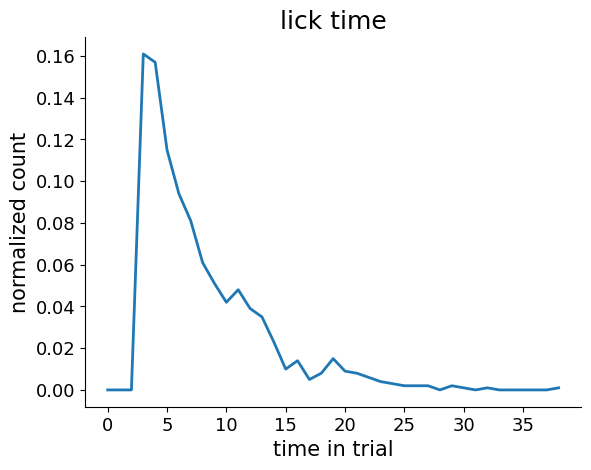

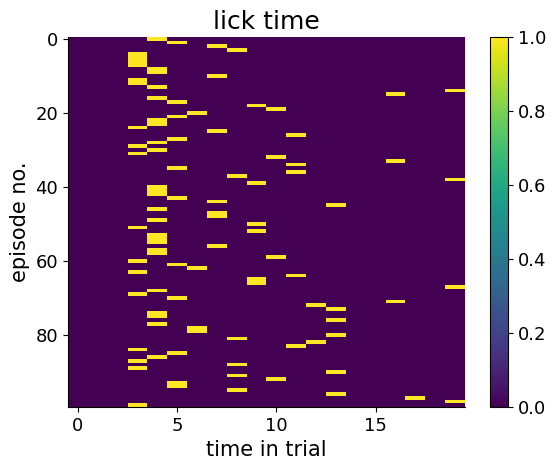

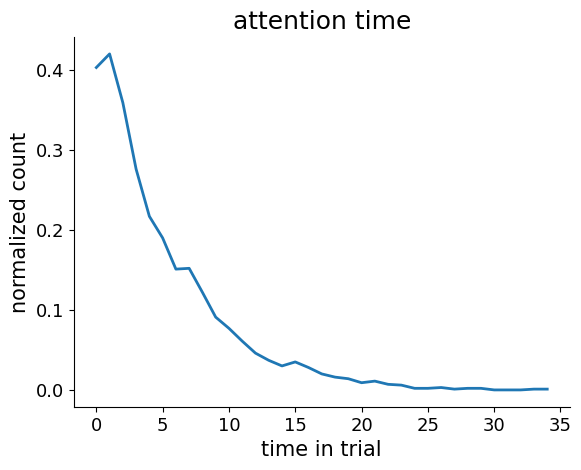

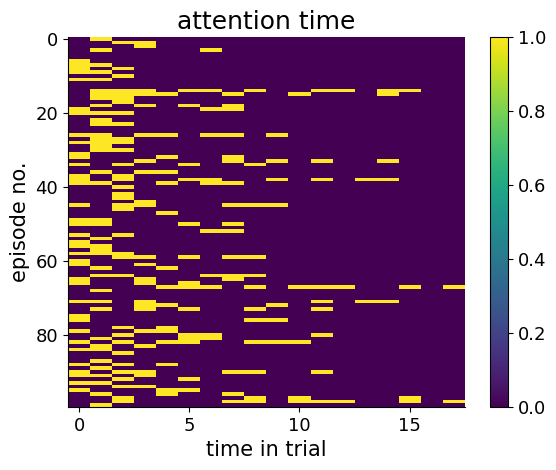

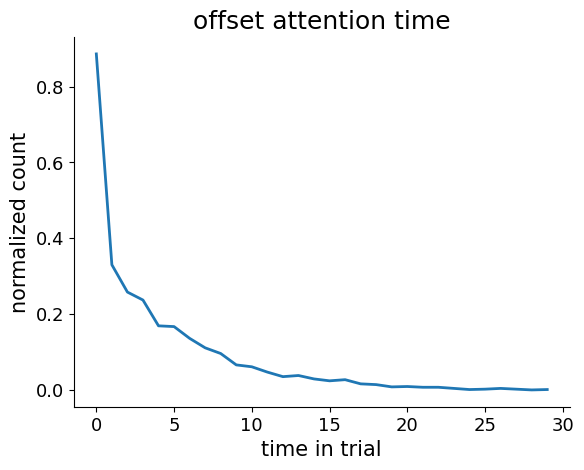

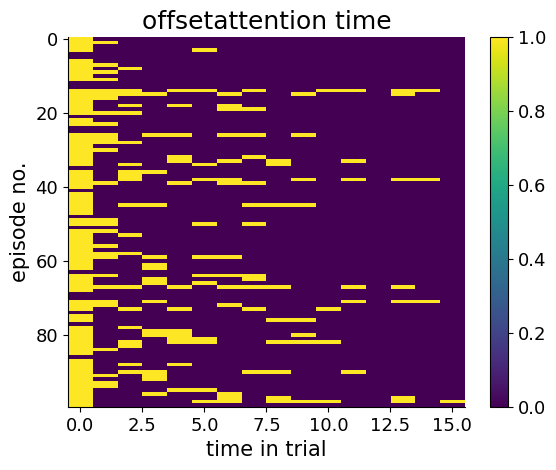

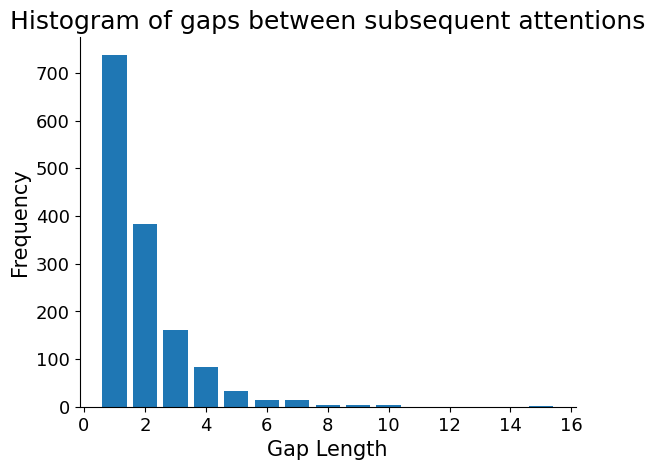

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from auditoryforage.AF_env import AuditoryForaging
from auditoryforage.utils import plot_AF_episode

import torch


def find_activation(agent, belief):
    features = torch.tensor(belief, dtype=torch.float32)
    with torch.no_grad():
        policy_net_0_results = agent.algo.policy.mlp_extractor.policy_net[0](
            features)
        policy_net_1_results = agent.algo.policy.mlp_extractor.policy_net[1](
            policy_net_0_results)
        policy_net_2_results = agent.algo.policy.mlp_extractor.policy_net[2](
            policy_net_1_results)
        policy_net_3_results = agent.algo.policy.mlp_extractor.policy_net[3](
            policy_net_2_results)
        policy_net_4_results = agent.algo.policy.mlp_extractor.policy_net[4](
            policy_net_3_results)
    return policy_net_4_results


def get_att_lick_probs(episode):
    activations_list = []
    for belief in episode['beliefs'][:-1]:  # Last belief is not used for action
        activations_list.append(find_activation(agent, belief).numpy())
    lick_feature = [activations_list[ind][0]
                    for ind in range(len(activations_list))]
    attention_feature = [activations_list[ind][1]
                         for ind in range(len(activations_list))]
    lick_prob = [(1/(1+np.exp(-2 * elt))) for elt in lick_feature]
    attention_prob = [(1/(1+np.exp(-2 * elt))) for elt in attention_feature]
    return attention_prob, lick_prob


def pad_lists(list_of_lists):
    max_length = max(len(lst) for lst in list_of_lists)
    padded_lists = [lst + [0] * (max_length - len(lst))
                    for lst in list_of_lists]
    return padded_lists


def pad_zero_lick(data):
    num_rows = len(data)
    num_cols = max(data) + 1
    grid = np.zeros((num_rows, num_cols))
    for i, arr in enumerate(data):
        grid[i, arr] = 1
    return grid


def pad_zero_attention(data):
    num_rows = len(data)
    num_cols = max(max(arr) for arr in data if len(arr) != 0) + 1
    grid = np.zeros((num_rows, num_cols))
    for i, arr in enumerate(data):
        grid[i, arr] = 1
    return grid


def offset_to_first(data):
    offset_data = [[x - min(inner_list) for x in inner_list]
                   for inner_list in data]
    return offset_data


def gap_histogram_all_rows(arr):
    gap_lengths = []
    for row in arr:
        count = 0
        for value in row:
            if value == 0:
                count += 1
            elif value == 1:
                if count > 0:
                    gap_lengths.append(count)
                    count = 0

    # Compute histogram for all gap lengths together
    histogram = np.histogram(
        gap_lengths, bins=np.arange(1, max(gap_lengths) + 2))
    return histogram


def plot_over_episodes(data, title, plot_no_episodes=100):

    if title == 'attention time':

        plt.figure()
        plt.plot(np.sum(pad_zero_attention(data), axis=0)/len(data))
        plt.xlabel('time in trial')
        plt.ylabel('normalized count')
        plt.title(title)
        plt.show()

        plot_data = data[:plot_no_episodes]
        plt.figure()
        c = plt.imshow(pad_zero_attention(plot_data), cmap='viridis',
                       aspect='auto', interpolation='none')
        plt.colorbar(c)
        plt.xlabel('time in trial')
        plt.ylabel('episode no.')
        plt.title(title)
        plt.show()

        plt.figure()
        plt.plot(np.sum(pad_zero_attention(
            offset_to_first(data)), axis=0)/len(data))
        plt.xlabel('time in trial')
        plt.ylabel('normalized count')
        plt.title('offset ' + title)
        plt.show()

        plot_data = offset_to_first(data[:plot_no_episodes])
        plt.figure()
        c = plt.imshow(pad_zero_attention(plot_data), cmap='viridis',
                       aspect='auto', interpolation='none')
        plt.colorbar(c)
        plt.xlabel('time in trial')
        plt.ylabel('episode no.')
        plt.title('offset' + title)
        plt.show()

        # plt.figure()
        # tot_sum = np.sum(pad_zero_attention(offset_to_first(data)), axis = 0)/len(data)
        # plt.plot(tot_sum[2:])
        # plt.xlabel('time in trial')
        # plt.ylabel('normalized count')
        # plt.title('offset and removed first ' + title)
        # plt.show()

        plt.figure()
        histogram = gap_histogram_all_rows(pad_zero_attention(data))
        plt.bar(histogram[1][:-1], histogram[0], width=0.8, align='center')
        plt.xlabel('Gap Length')
        plt.ylabel('Frequency')
        plt.title('Histogram of gaps between subsequent attentions')
        plt.show()

    elif title == 'lick time':

        plt.figure()
        plt.plot(np.sum(pad_zero_lick(data), axis=0)/len(data))
        plt.xlabel('time in trial')
        plt.ylabel('normalized count')
        plt.title(title)
        plt.show()

        plot_data = data[:plot_no_episodes]
        plt.figure()
        c = plt.imshow(pad_zero_lick(plot_data), cmap='viridis',
                       aspect='auto', interpolation='none')
        plt.colorbar(c)
        plt.xlabel('time in trial')
        plt.ylabel('episode no.')
        plt.title(title)
        plt.show()

    else:

        plt.figure()
        plt.plot(np.sum(pad_lists(data), axis=0)/len(data))
        plt.xlabel('time in trial')
        plt.ylabel('normalized count')
        plt.title(title)
        plt.show()

        plot_data = data[:plot_no_episodes]
        plt.figure()
        c = plt.imshow(pad_lists(plot_data), cmap='viridis',
                       aspect='auto', interpolation='none')
        plt.colorbar(c)
        plt.xlabel('time in trial')
        plt.ylabel('episode no.')
        plt.title(title)
        plt.show()


env_param = [0, 1200, 0.087213, .25, -30, 0, 0]
env = AuditoryForaging(spec={'agent': {'lick_cost': env_param[0], 'food_reward': env_param[1], 'attention_cost_coeff': env_param[2],
                       'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
num_epochs = 1
agent = manager.train_agent(env_param, num_epochs=num_epochs, seed=3)

attention_prob_list = []
lick_prob_list = []
lick_time_list = []
att_time_list = []

num_episodes = 1000

for ep_no in range(num_episodes):
    episode = agent.run_one_episode(env=env, num_steps=10000, q_states=[
                                    [i] for i in range(env.no_nodes)])
    att_time_list.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
    attention_prob, lick_prob = get_att_lick_probs(episode)
    attention_prob_list.append(attention_prob)
    lick_prob_list.append(lick_prob)

    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))


plot_over_episodes(attention_prob_list,
                   title='attention prob.', plot_no_episodes=100)
plot_over_episodes(lick_prob_list, title='lick prob.', plot_no_episodes=100)
plot_over_episodes(lick_time_list, title='lick time', plot_no_episodes=100)
plot_over_episodes(att_time_list, title='attention time', plot_no_episodes=100)